In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [9]:
titanic = sns.load_dataset("titanic")

# the features we will work with
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# Handle missing values
imp_median = SimpleImputer(strategy= "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy= "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# Encoding
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# Decision Tree
model = DecisionTreeClassifier(max_depth=4) 
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy:", accuracy_score(y_train, y_pred_train)*100,"%")
print("Testing accuracy:", accuracy_score(y_test, y_pred_test)*100,"%")
# Classic case of overfitting - training accuracy much higher than testing accuracy

Training accuracy: 84.75120385232745 %
Testing accuracy: 82.46268656716418 %


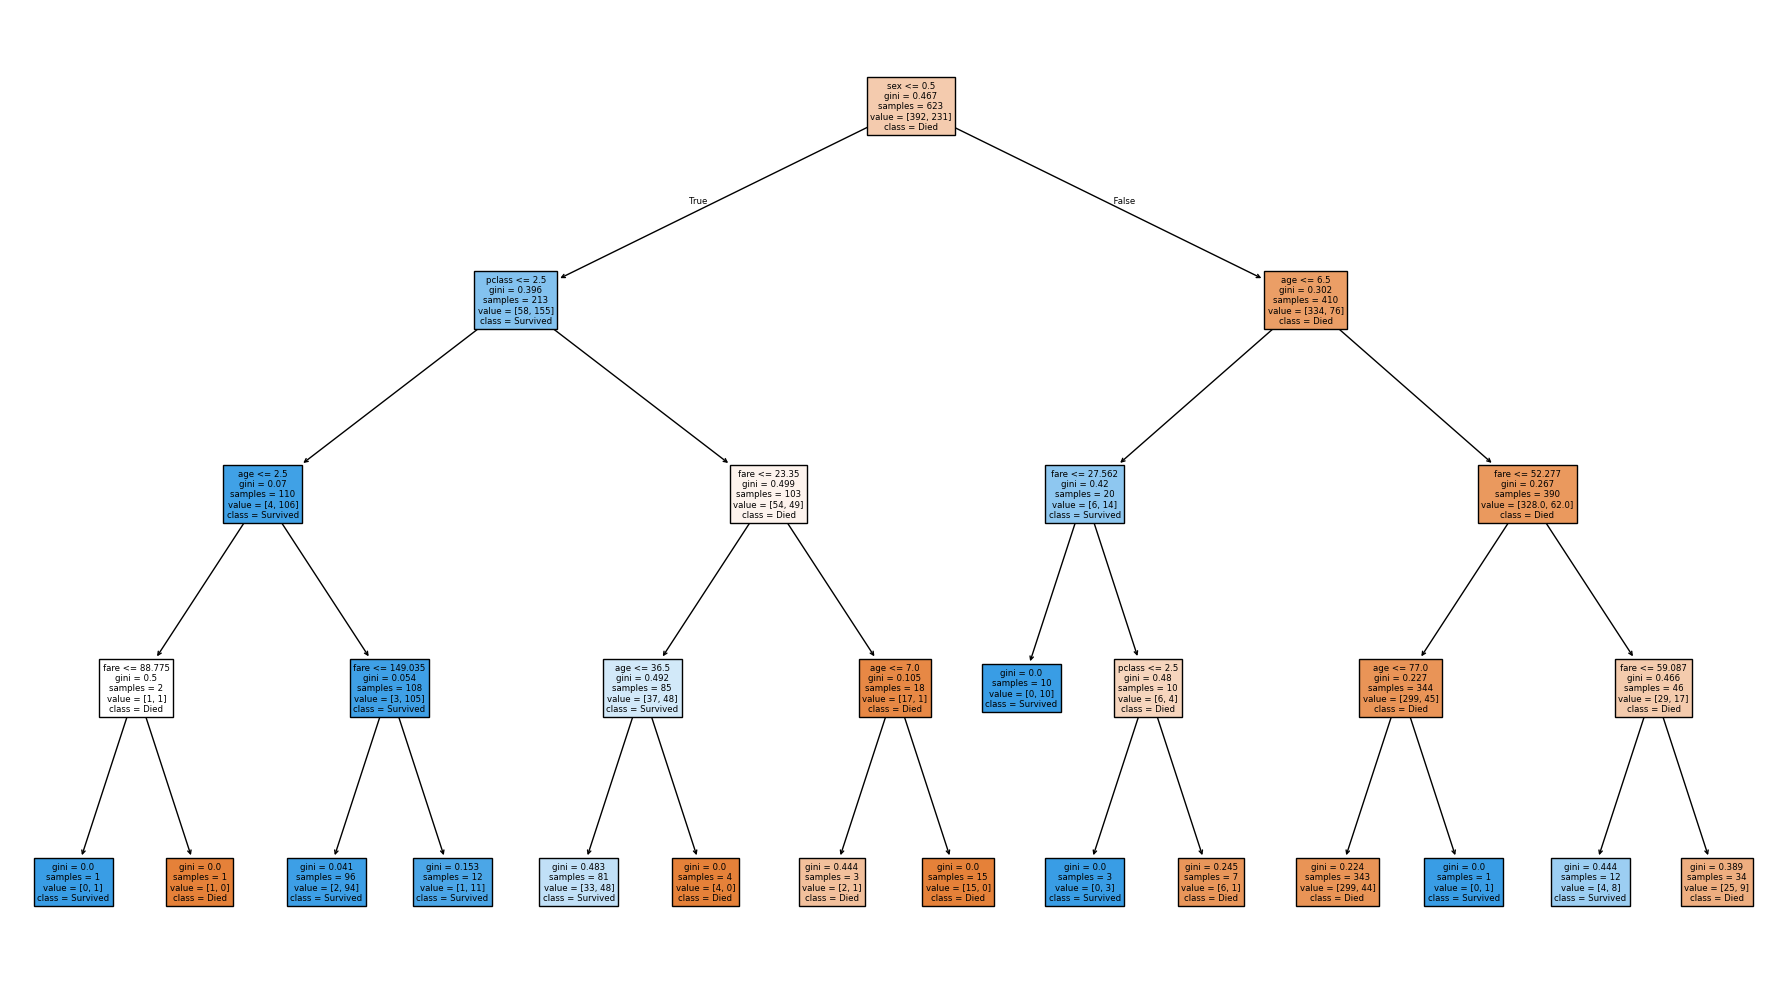

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
    #max_depth=2 # only show top 2 levels
)

plt.tight_layout()
plt.show()

In [22]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators= 501,
    oob_score=True,
    max_depth=4
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB score", rf.oob_score_ * 100, "%")  # equivalent to training accuracy
print("Accuracy score:", accuracy_score(y_test, y_pred)* 100, "%") # more stable performance than normal DT


OOB score 81.70144462279293 %
Accuracy score: 81.71641791044776 %


In [30]:
# Bagging Classifier - Decision Tree Classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier() 

bagging = BaggingClassifier(
    base_model,
    n_estimators= 201
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_pred)* 100, "%")

Accuracy score: 76.49253731343283 %


In [31]:
# Bagging Classifier - Logistic regression
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000) 

bagging = BaggingClassifier(
    base_model,
    n_estimators= 201
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_pred)* 100, "%")

Accuracy score: 79.47761194029852 %
